# Render one clean fragmentation frame

This notebook reuses the OVITO/Tachyon atom rendering style from `render_single.py`, but writes only the atom/bond image. There is no statistics panel. Adjust the camera controls below to change the view angle and zoom.

In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np
from PIL import Image
from IPython.display import display

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "render_single.py").exists():
    PROJECT_DIR = Path("/home/zhuang652/research/ML_frag_EMIBF4/Datacopy/New_case_EMIBF4_wall_collision/Data_Wall_collision_Law_mace/new_analysis/Visual_new")

sys.path.insert(0, str(PROJECT_DIR))
import render_single as rs
importlib.reload(rs)

PROJECT_DIR


PosixPath('/home/zhuang652/research/ML_frag_EMIBF4/Datacopy/New_case_EMIBF4_wall_collision/Data_Wall_collision_Law_mace/new_analysis/Visual_new')

(PosixPath('/home/zhuang652/research/ML_frag_EMIBF4/Datacopy/New_case_EMIBF4_wall_collision/Data_Wall_collision_Law_mace/new_analysis/Visual_new/data_wall_collision/E50_Y45_Z90.xyz'),
 PosixPath('/home/zhuang652/research/ML_frag_EMIBF4/Datacopy/New_case_EMIBF4_wall_collision/Data_Wall_collision_Law_mace/new_analysis/Visual_new/single_frame_renders/E50_Y45_Z90_frame_0120_atoms_only.png'))

In [3]:
def trajectory_frame_count(pipeline):
    source = pipeline.source
    if hasattr(source, "num_frames"):
        return int(source.num_frames)
    return int(source.numframes)


def spherical_camera(look_at, distance, azimuth_deg, elevation_deg):
    az = np.radians(azimuth_deg)
    el = np.radians(elevation_deg)
    offset = np.array([
        distance * np.cos(el) * np.cos(az),
        distance * np.cos(el) * np.sin(az),
        distance * np.sin(el),
    ])
    cam_pos = look_at + offset
    cam_dir = look_at - cam_pos
    cam_dir = cam_dir / np.linalg.norm(cam_dir)
    return cam_pos, cam_dir


def render_atoms_only_frame(
    xyz_path,
    frame_num,
    output_png,
    render_size=(1920, 1080),
    background=(1.0, 1.0, 1.0),
    azimuth_deg=-90.0,
    elevation_deg=12.0,
    distance=70.0,
    fov_deg=30.0,
    look_at_z=27.0,
):
    xyz_path = Path(xyz_path)
    output_png = Path(output_png)
    output_png.parent.mkdir(parents=True, exist_ok=True)

    pipeline = rs.setup_pipeline(str(xyz_path))
    n_frames = trajectory_frame_count(pipeline)
    if frame_num < 0 or frame_num >= n_frames:
        raise ValueError(f"FRAME_NUM must be between 0 and {n_frames - 1}; got {frame_num}")

    data0 = pipeline.compute(0)
    cell = data0.cell
    cell_cx = cell[0, 3] + cell[0, 0] / 2
    cell_cy = cell[1, 3] + cell[1, 1] / 2

    frag_info = rs.analyze_fragment_composition(pipeline, frame_num)
    target_z = frag_info["center_z"] if look_at_z is None else float(look_at_z)
    look_at = np.array([cell_cx, cell_cy, target_z])
    cam_pos, cam_dir = spherical_camera(look_at, distance, azimuth_deg, elevation_deg)

    pipeline.add_to_scene()
    pipeline.source.data.cell.vis.enabled = False
    try:
        renderer = rs.TachyonRenderer(
            ambient_occlusion=True,
            ambient_occlusion_brightness=0.6,
            ambient_occlusion_samples=12,
            antialiasing=True,
            antialiasing_samples=12,
            shadows=True,
            direct_light=True,
            direct_light_intensity=0.85,
        )

        vp = rs.Viewport(type=rs.Viewport.Type.Perspective)
        vp.fov = np.radians(fov_deg)
        vp.camera_pos = tuple(cam_pos)
        vp.camera_dir = tuple(cam_dir)
        vp.render_image(
            size=render_size,
            filename=str(output_png),
            renderer=renderer,
            frame=frame_num,
            background=background,
        )
    finally:
        pipeline.remove_from_scene()

    return output_png, frag_info, n_frames, cam_pos, look_at


(PosixPath('/home/zhuang652/research/ML_frag_EMIBF4/Datacopy/New_case_EMIBF4_wall_collision/Data_Wall_collision_Law_mace/new_analysis/Visual_new/data_wall_collision/E50_Y45_Z90.xyz'),
 PosixPath('/home/zhuang652/research/ML_frag_EMIBF4/Datacopy/New_case_EMIBF4_wall_collision/Data_Wall_collision_Law_mace/new_analysis/Visual_new/single_frame_renders/E50_Y45_Z90_frame_0000_atoms_only.png'))

Rendered frame 120 of 400: /home/zhuang652/research/ML_frag_EMIBF4/Datacopy/New_case_EMIBF4_wall_collision/Data_Wall_collision_Law_mace/new_analysis/Visual_new/single_frame_renders/E50_Y45_Z90_frame_0120_atoms_only.png
Fragments detected: 6
Camera position: [ 11.53998267 -58.4764139   41.55381836]
Look-at point: [11.53998267  9.99391815 27.        ]


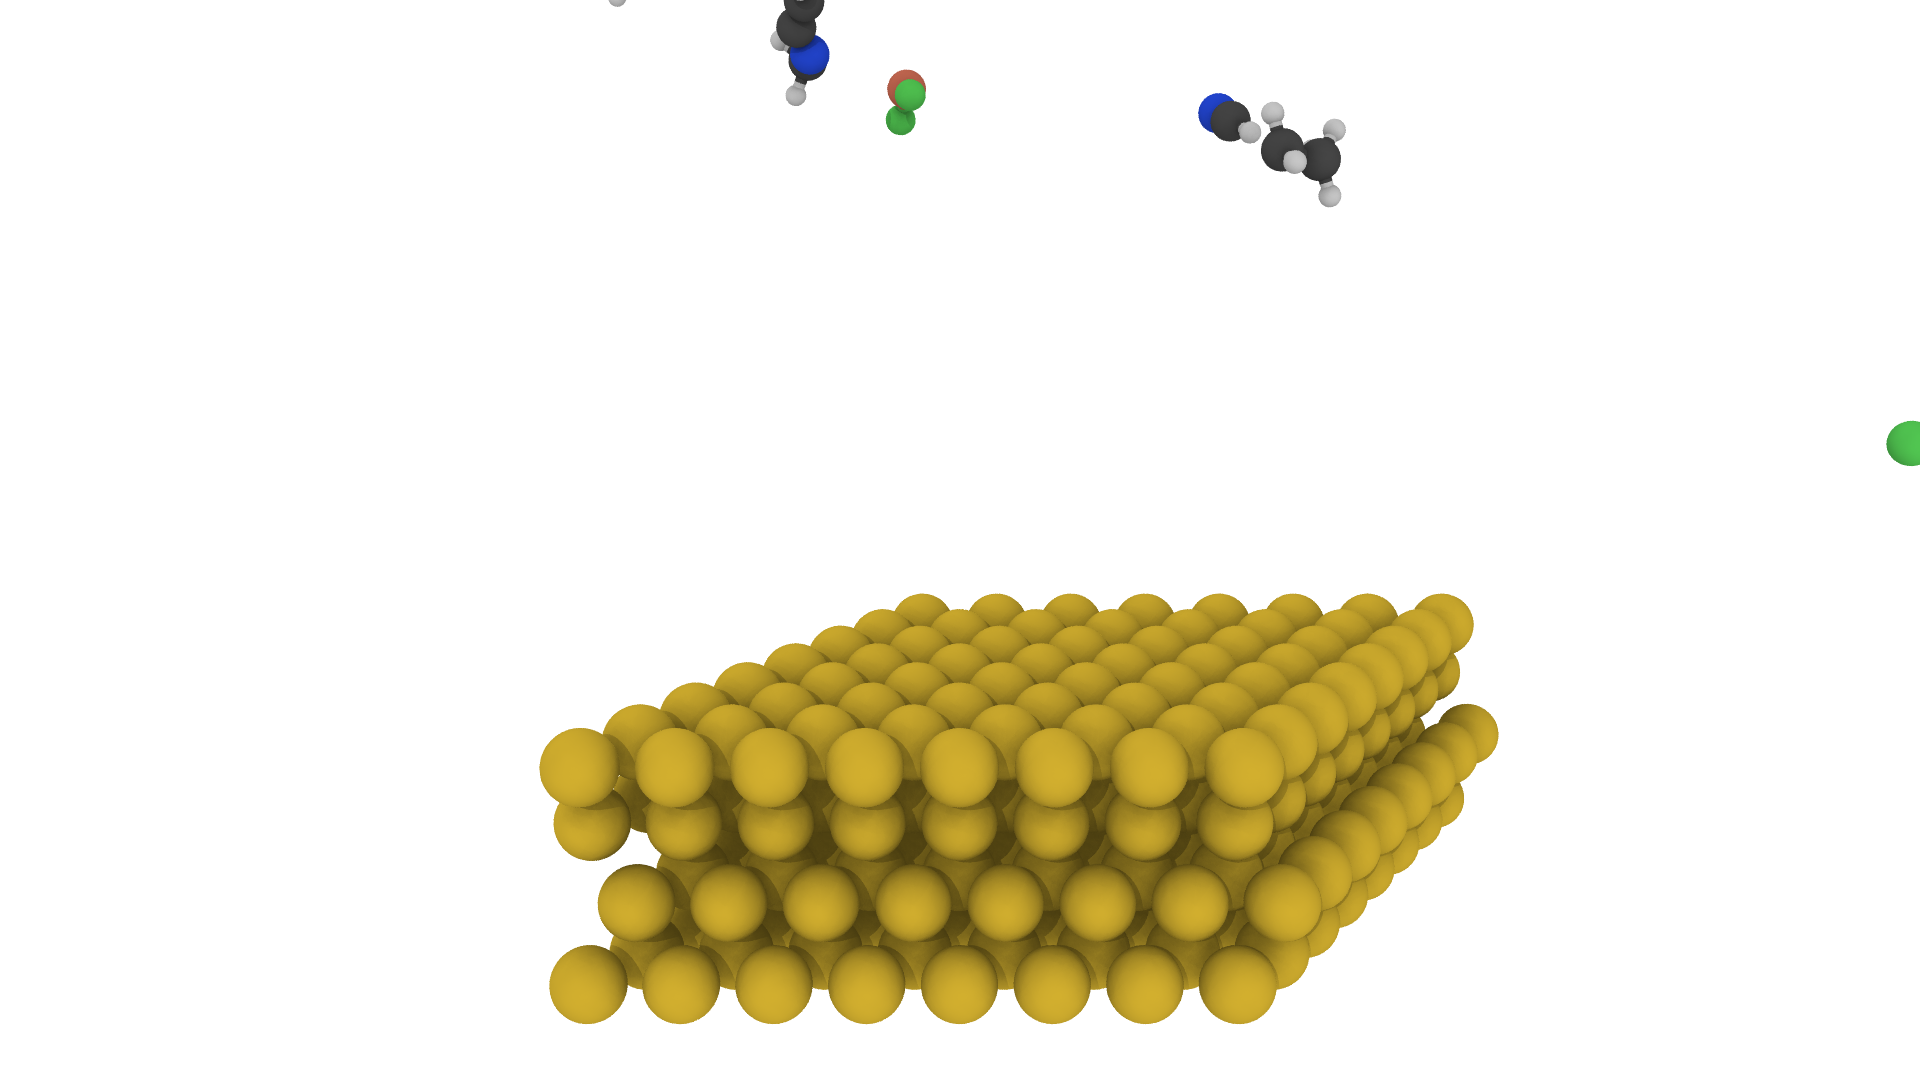

In [ ]:
# Trajectory/frame selection
XYZ_PATH = PROJECT_DIR / "data_wall_collision" / "E50_Y45_Z90.xyz"
FRAME_NUM = 0
# Output
OUTPUT_DIR = PROJECT_DIR / "single_frame_renders"
OUTPUT_PNG = OUTPUT_DIR / f"{XYZ_PATH.stem}_frame_{FRAME_NUM:04d}_atoms_only.png"
RENDER_SIZE = (1920, 1080)
BACKGROUND = (1.0, 1.0, 1.0)

# Camera controls. Change these and rerun the render cell.
# Azimuth rotates around the vertical z axis; elevation tilts up/down.
CAMERA_AZIMUTH_DEG = -90.0
CAMERA_ELEVATION_DEG = 12.0
CAMERA_DISTANCE = 70.0
CAMERA_FOV_DEG = 30.0

# The camera points at this z height. None uses the molecule center at FRAME_NUM.
# A fixed value near 27.0 keeps the Au wall and outgoing fragments in view.
LOOK_AT_Z = 27.0

XYZ_PATH, OUTPUT_PNG



output_png, frag_info, n_frames, cam_pos, look_at = render_atoms_only_frame(
    XYZ_PATH,
    FRAME_NUM,
    OUTPUT_PNG,
    render_size=RENDER_SIZE,
    background=BACKGROUND,
    azimuth_deg=CAMERA_AZIMUTH_DEG,
    elevation_deg=CAMERA_ELEVATION_DEG,
    distance=CAMERA_DISTANCE,
    fov_deg=CAMERA_FOV_DEG,
    look_at_z=LOOK_AT_Z,
)

print(f"Rendered frame {FRAME_NUM} of {n_frames - 1}: {output_png}")
print(f"Fragments detected: {frag_info['n_fragments']}")
print(f"Camera position: {cam_pos}")
print(f"Look-at point: {look_at}")
display(Image.open(output_png))


Suggested starting views: `CAMERA_AZIMUTH_DEG = -90` for the original side view, `-60` for a diagonal view, `0` or `180` for front/back views. Increase `CAMERA_DISTANCE` or `CAMERA_FOV_DEG` if fragments are clipped.